   R&D Spend  Administration  Marketing Spend       State     Profit  Cluster
0  165349.20       136897.80        471784.10    new york  192261.83        0
1  162597.70       151377.59        443898.53  california  191792.06        0
2  153441.51       101145.55        407934.54     florida  191050.39        0
3  144372.41       118671.85        383199.62    new york  182901.99        0
4  142107.34        91391.77        366168.42     florida  166187.94        0

Cluster Count:
Cluster
0    24
1    16
2    10
Name: count, dtype: int64

Cluster Summary:
             R&D Spend  Administration  Marketing Spend         Profit
Cluster                                                               
0        111005.897083   124945.030417    308551.979167  143930.745000
1         42946.116250   139530.753750     88650.001875   84864.885625
2         33480.139000    83605.919000    172760.736000   78845.591000


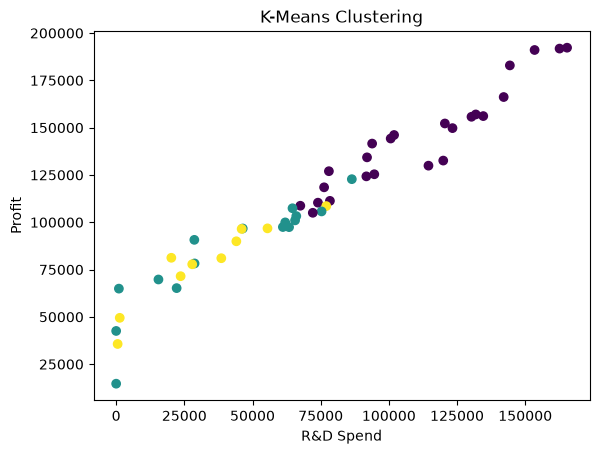

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("50_Startups.csv")

# Clean text column (NLP preprocessing)
df["State"] = df["State"].str.lower().str.strip()

# Features
X = df.drop("Profit", axis=1)

# Encode State + scale numerical data
pre = ColumnTransformer([
    ("num", StandardScaler(),
     ["R&D Spend", "Administration", "Marketing Spend"]),
    ("text", OneHotEncoder(), ["State"])
])

X = pre.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Results
print(df.head())
print("\nCluster Count:")
print(df["Cluster"].value_counts())

print("\nCluster Summary:")
print(df.groupby("Cluster")[["R&D Spend", "Administration",
                             "Marketing Spend", "Profit"]].mean())

# Plot
plt.scatter(df["R&D Spend"], df["Profit"], c=df["Cluster"])
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("K-Means Clustering")
plt.show()